# Data analysis

This notebook assumes the previous execution of the `tools/filter.sh` script to generate a CSV from the raw PCAP file.

`filter.sh` is a simple script for tshark.

## Handling big files
Leverage `-c` option to select a capture subset. For example:

```sh
if [ -z "$1" ]; then
    echo "Usage: $0 <filename.pcap>"
    exit 1
fi

FILENAME_BASE="${1%.*}"

tshark -r $1 -T fields \
  -e frame.number \
  -e frame.time_relative \
  -e frame.time_delta \
  -e frame.len \
  -e ip.src -e ip.dst \
  -e ip.proto \
  -e tcp.srcport -e tcp.dstport \
  -e udp.srcport -e udp.dstport \
  -c 10000
  -E header=y -E separator=, -E quote=d > ${FILENAME_BASE}-10000.csv
```

## Introduction
The notebook is structured as follows:

- Packet level analysis
  + Packet size: fit with bimodal distribution
  + Inter-arrival time: fit with Poisson distribution

To evaluate the goodness of fit, I calculate the $R^2$ and $RMSE$ using the functions provided below.

\begin{equation}
    R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
\end{equation}

$\overline{y}$ is the mean of the initial dataset. $y_i$ is a point of the initial dataset. $f_{i}$ is a point of the fitted distribution. 

$SS_{res}$ is the sum of square of residual. It indicates how much data fitted in the model differs from the mean value of original data (we take always the sum of squares to remove negative values).
\begin{equation}
    SS_{res} = \sum_{i=1}^n (y_i - f_i)^2
\end{equation}

$SS_{tot}$ is the total sum of squares. It is obtained with the difference between $y_i$ and $\overline{y}$
\begin{equation}
    SST = \sum_{i=1}^n (y_i - \overline{y})^2
\end{equation}

$RMSE$ is the mean distance between predicted data and original data squared:

\begin{equation}
       RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i - f_i)^2}
\end{equation}


In [58]:
import numpy as np

def rsquared_rmse(predicted_data: np.ndarray, observed_data: np.ndarray) -> float:
    residuals = observed_data - predicted_data
    
    sse = np.sum(residuals ** 2)
    
    sst = np.sum((observed_data - np.mean(observed_data)) ** 2)

    r_squared = 1 - (sse / sst) 
    rmse = np.sqrt(np.mean(residuals**2))
    
    return rsquared, rmse   

In [54]:
import pandas as pd

fname = "dataset/201302011400-4096.csv"

df = pd.read_csv(fname)

df.head()

,frame.number,frame.time_relative,frame.time_delta,frame.len,ip.src,ip.dst,ip.proto,tcp.srcport,tcp.dstport,udp.srcport,udp.dstport
0,1,0.000000,NaN,1514,200.11.79.20,140.198.115.132,6,80.0,52021.0,NaN,NaN
1,2,0.000003,0.000003,1514,200.11.79.20,140.198.115.132,6,80.0,52021.0,NaN,NaN
2,3,0.000006,0.000003,1514,200.11.79.20,140.198.115.132,6,80.0,52021.0,NaN,NaN
3,4,0.000009,0.000003,94,167.180.134.255,32.218.92.255,1,NaN,NaN,NaN,NaN
4,5,0.000012,0.000003,66,55.146.64.212,211.83.168.117,6,49191.0,3389.0,NaN,NaN


# Packet size analysis

First, we extract the packet_size from the `frame.len` field of the initial dataset.

Looking at the distribution plotted, it could be fit with the **bimodal** distribution. This can be explained as follows:

- **left peak**: small size packet usually used control traffic (handshake, acks)
- **right peak**: `~1500` bytes packets. Most OS tend to use all availble MTU for frames

The bimodal distribution is the sum of 2 gaussian. We need to estimate $\mu_1, \sigma_1$ and $\mu_2, \sigma_2$. This can be done by looking at data we have and using `curve_fit` from the `scipy.optimize` module. To speed up, we can tell the optimizer an initial guess. We know the left peak and right peak *x* position, so we can use them.

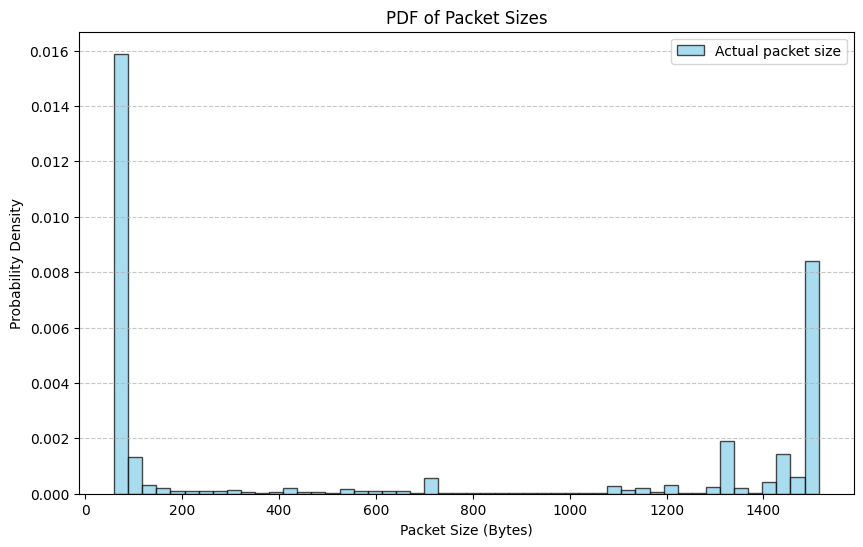

0    1514
1    1514
2    1514
3      94
4      66
Name: frame.len, dtype: int64
Estimated params: [7.42607148e+01 1.31769108e+01 1.58842525e-02 1.52291955e+03
 2.07982648e+01 1.58842525e-02]
R-squared: <function rsquared at 0x7f733ec2ca60>
RMSE: 0.0003689292866350971


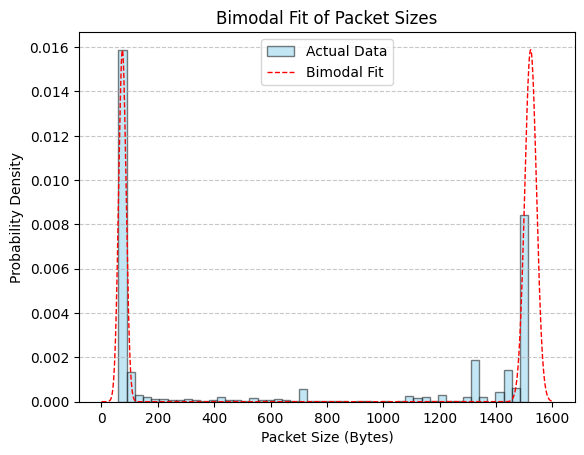

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

bins = 50

# Create the bimodal from the sum of 2 gaussian
def gauss(x,mu,sigma,A):
    return A * np.exp(-(x-mu)**2/2 /sigma**2)

def bimodal(x,mu1,sigma1,A1,mu2,sigma2,A2):
    return gauss(x,mu1,sigma1,A1) + gauss(x,mu2,sigma2,A2)

packet_sizes = df["frame.len"].dropna()

pdf = plt.figure(figsize=(10, 6))

plt.hist(packet_sizes, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.7, label="Actual packet size")
plt.title('PDF of Packet Sizes')
plt.xlabel('Packet Size (Bytes)')
plt.ylabel('Probability Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(packet_sizes.head())
# Save the single pdf for reference.
plt.savefig("figures/pdf-packet_size.pdf")
plt.close(pdf)

# Create a histogram to get the (x, y) coordinates for fitting
counts, bin_edges = np.histogram(packet_sizes, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
max_height = np.max(counts)

# Peak 1 is around 60, Peak 2 is around 1500.
# format: [mu1, sigma1, amp1, mu2, sigma2, amp2]
initial_guess = [60, 20, max_height, 1500, 20, max_height / 2]
lower_bounds = [0, 1, 0, 1000, 1, 0]          # Minimum allowed values
upper_bounds = [500, 200, max_height, 1600, 200, max_height] # Maximum allowed values

# Find optimal parameters
params, cov = curve_fit(bimodal, 
                        bin_centers, 
                        counts, 
                        p0=initial_guess, 
                        bounds=(lower_bounds, upper_bounds),
                        maxfev=1000
                       )

# Plot origial data
# Use 1500 / 50 = 30 bytes per bin 
plt.hist(packet_sizes, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.5, label="Actual Data")

# Plot the bimodal-distribution
x_range = np.linspace(0, 1600, 1000)
plt.plot(x_range, bimodal(x_range, *params), color='red', linestyle="--", lw=1, label='Bimodal Fit')

plt.title('Bimodal Fit of Packet Sizes')
plt.xlabel('Packet Size (Bytes)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
print("Estimated params:", params)
plt.savefig("figures/bimodalfit-packet-size.pdf")

# Goodness of fit evaluation
y_predicted = bimodal(bin_centers, *params)
y_actual = counts

r_squared, rmse = rsquared_rmse(y_predicted, y_actual)
print("R-squared:", r_squared)
print("RMSE:", rmse)

# Inter-arrival time analysis

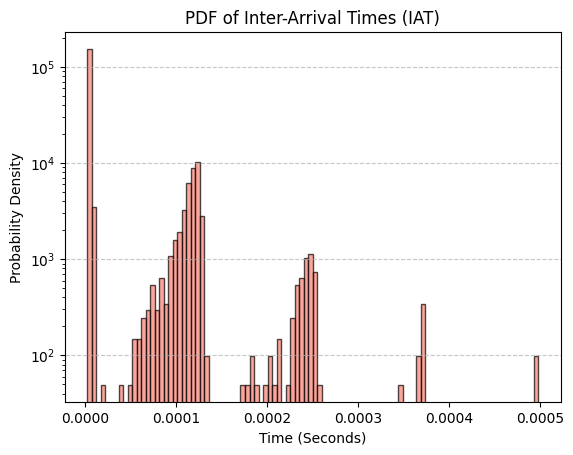

In [8]:
import matplotlib.pyplot as plt

iat_data = df["frame.time_delta"].dropna()

plt.hist(iat_data, bins=100, density=True, color='salmon', edgecolor='black', alpha=0.7)
plt.title('PDF of Inter-Arrival Times (IAT)')
plt.xlabel('Time (Seconds)')
plt.ylabel('Probability Density')
plt.yscale('log') # Useful if you have a few very large gaps
plt.grid(axis='y', linestyle='--', alpha=0.7)